In [4]:
import scipy.io as io
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.unumpy as unp

In [5]:
import matplotlib
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

In [6]:
os.getcwd()

'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges'

In [4]:
%matplotlib notebook

In [36]:
font = {'family' : 'Microsoft Sans Serif',
        'weight' : 'bold',
        'size'   : 8}

matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=0.5, edgecolor='k')

In [37]:
def powerlaw(x,a,b,c):
    return a*x**b+c
def quad(x, a, b, c):
    return a*x**2 + b*x + c

In [38]:
dissipated_power_factor = 0.69

if dissipated_power_factor != 0.69:
    avg_flag = True
else:
    avg_flag = False

In [39]:
t1_theory = np.load('T1theoryBBQPPurcell.npy')
t2_theory = np.load('T2DeltatheorySN.npy')

In [40]:
# Pavg, T1s*1e6, T1sprep*1e6, Trabs*1e6, T2s_new*1e6, T2sprep*1e6, unp.nominal_values(Tphis_unp)*1e6
new_t_data = np.load('20231020_t1_exp_data.npy')
new_t_err = np.load('20231020_t1_exp_error.npy')

In [41]:
data_exp = np.load('mode_temp_data.npy') # trigger, fridge, qubit, qubit cav temp, EO cav temp
data_new = np.load('20231023_mode_temp_data.npy') # triggers, Tsfridge, Tsqu*1000, Tsqu_err*1000, Tscav*1000, Tscav_stdev*1000, TscavEO*1000, TscavEO_error*1000
calibration = np.load('TriggerVSoptpwr_fit.npy')*dissipated_power_factor
calibration[0][1] = 0
calibration = np.poly1d(calibration[0])
eo = np.array([0.139, 0.445, 0.947, 1.190, 1.626])*1000
eo_err = np.array([0.022, 0.012, 0.012, 0.012, 0.012])*1000
data_exp[0]

array([   0.,   10.,   50.,  250.,  500., 1000.])

In [48]:
#see Fit_QubitTemp
data_new[2] = np.asarray([0.0656,0.06687,0.07953,0.1111,0.1270,0.1613])*1000
data_new[3] = np.asarray([0.0004,0.00026,0.00033,0.0007,0.0011,0.0025])*1000

In [49]:
data_new

array([[0.000e+00, 1.000e+01, 5.000e+01, 2.500e+02, 5.000e+02, 1.000e+03],
       [7.000e+00, 1.800e+01, 3.400e+01, 7.400e+01, 1.040e+02, 1.430e+02],
       [6.560e+01, 6.687e+01, 7.953e+01, 1.111e+02, 1.270e+02, 1.613e+02],
       [4.000e-01, 2.600e-01, 3.300e-01, 7.000e-01, 1.100e+00, 2.500e+00],
       [8.250e+01, 8.240e+01, 8.290e+01, 1.012e+02, 1.362e+02, 1.842e+02],
       [2.400e+00, 2.900e+00, 3.400e+00, 2.900e+00, 1.300e+00, 1.900e+00],
       [      nan, 1.390e+02, 4.450e+02, 9.470e+02, 1.190e+03, 1.626e+03],
       [      nan, 3.100e+01, 1.700e+01, 1.700e+01, 1.700e+01, 1.700e+01]])

<IPython.core.display.Javascript object>


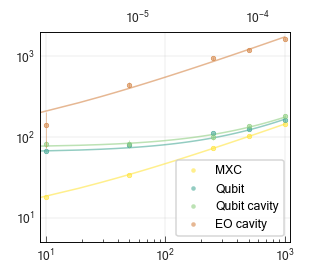

In [55]:
# colors = ['#64dd17', '#c0ca33', '#ffab00', '#ef6c00']
colors = ['#ffe540', '#4bab99', '#90cf82', '#d6884b']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.95,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1
elw = 0.5

ax1.set_xlim([9,1100])
ax12 = ax1.twiny()
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])

data_exp [0][0] = 3

xp = np.linspace(9, 1000, 100)
ax1.plot(xp,powerlaw(xp,*[3.3, 0.54, 7]), lw=lw, alpha=0.6, c=colors[0]) # fridge
ax1.plot(xp,powerlaw(xp,*[40, 0.54, 70]), lw=lw, alpha=0.6, c=colors[3]) # EO cav
pboth = np.poly1d([-1.5e-05,  9.6e-02,  62])
ax1.plot(xp,powerlaw(xp, *[0.35, 0.82, 65]), lw=lw, alpha=0.6, c=colors[1]) # qubit
ax1.plot(xp,powerlaw(xp, *[0.35, 0.82, 75]), lw=lw, alpha=0.6, c=colors[2]) # qubit cav


ax1.plot(data_exp[0], data_new[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], data_new[2], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], data_new[4], '.', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0, 1:], eo, '.', mec=colors[3], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

ax1.plot(data_exp[0], data_new[1], '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.6, label='MXC')
ax1.plot(data_exp[0], data_new[2], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.6, label = 'Qubit')
ax1.plot(data_exp[0], data_new[4], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.6, label = 'Qubit cavity')
ax1.plot(data_exp[0, 1:], eo, '.', mec=colors[3], ms=ms, mew = 0, mfc=colors[3], alpha=0.6, label = 'EO cavity')
ax1.errorbar(data_exp[0], data_new[2], yerr=3*data_new[3], fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
ax1.errorbar(data_exp[0], data_new[4], yerr=3*data_new[5], fmt= 'none', mec=colors[2], ms=ms, mew = 0, elinewidth=elw, mfc=colors[2], ecolor=colors[2], alpha=0.6)
ax1.errorbar(data_exp[0, 1:], eo, yerr=3*eo_err, fmt='none', mec=colors[3], ms=ms, mew = 0, elinewidth=elw, mfc=colors[3], ecolor=colors[3], alpha=0.6)



ax1.set_yscale('log')
ax1.set_xscale('log')

ax12.set_xscale('log')

ax1.grid(linewidth = 0.3, alpha=0.5)
ax1.set_ylim([5,2000])
temp= ax1.get_ylim()

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=False, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax12.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)

ax1.legend()

# ax1.set_xlim([-0.0,4.1])
# ax1.set_ylim([0.0,0.95])
# ax1.xaxis.set_major_locator(MultipleLocator(1))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
# ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

# ax1.yaxis.set_major_locator(MultipleLocator(0.2))
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

# plt.savefig('fig4b.svg')
# plt.savefig('fig4b.pdf')

In [56]:
data_exp = np.load('mode_temp_data.npy') # trigger, fridge, qubit, qubit cav temp, EO cav temp
data_new = np.load('20231023_mode_temp_data.npy') # triggers, Tsfridge, Tsqu*1000, Tsqu_err*1000, Tscav*1000, Tscav_stdev*1000, TscavEO*1000, TscavEO_error*1000
data_new[2] = np.asarray([0.0656,0.06687,0.07953,0.1111,0.1270,0.1613])*1000
data_new[3] = np.asarray([0.0004,0.00026,0.00033,0.0007,0.0011,0.0025])*1000
save_data_exp = data_exp

<IPython.core.display.Javascript object>


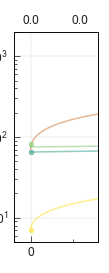

In [57]:
# colors = ['#64dd17', '#c0ca33', '#ffab00', '#ef6c00']
colors = ['#ffe540', '#4bab99', '#90cf82', '#d6884b']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(1,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1
elw = 0.5

ax1.set_xlim([-2,8])
ax12 = ax1.twiny()
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])


xp = np.linspace(0, 9, 100)
ax1.plot(xp,powerlaw(xp,*[3.3, 0.54, 7]), lw=lw, alpha=0.6, c=colors[0], label='Fridge') # fridge
ax1.plot(xp,powerlaw(xp,*[40, 0.54, 70]), lw=lw, alpha=0.6, c=colors[3], label = 'EO cavity') # EO cav
pboth = np.poly1d([-1.5e-05,  9.6e-02,  62])
ax1.plot(xp,powerlaw(xp, *[0.35, 0.82, 65]), lw=lw, alpha=0.6, c=colors[1], label = 'Qubit') # qubit
ax1.plot(xp,powerlaw(xp, *[0.35, 0.82, 75]), lw=lw, alpha=0.6, c=colors[2], label = 'Qubit cavity') # qubit cav


ax1.plot(data_exp[0], data_new[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], data_new[2], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], data_new[4], '.', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax1.plot(data_exp[0], data_new[6], '.', mec=colors[3], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

ax1.plot(data_exp[0], data_new[1], '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.6)
ax1.errorbar(data_exp[0], data_new[2], yerr=3*data_new[3], fmt='.', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
ax1.errorbar(data_exp[0], data_new[4], yerr=3*data_new[5], fmt= '.', mec=colors[2], ms=ms, mew = 0, elinewidth=elw, mfc=colors[2], ecolor=colors[2], alpha=0.6)
# ax1.errorbar(data_exp[0], data_new[6], yerr=3*data_new[7], fmt='.', mec=colors[3], ms=ms, mew = 0, elinewidth=elw, mfc=colors[3], ecolor=colors[3], alpha=0.6)



ax1.set_yscale('log')
# ax1.set_xscale('log')
ax1.set_ylim(temp)

# ax12.set_xscale('log')

ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)



ax12.xaxis.set_major_locator(MultipleLocator(0.000001))
ax12.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax12.xaxis.set_minor_locator(MultipleLocator(0.0000005))

ax1.xaxis.set_major_locator(MultipleLocator(10))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(5))

# ax1.yaxis.set_major_locator(MultipleLocator(0.2))
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax1.yaxis.set_minor_locator(MultipleLocator(0.1))
# if avg_flag:
#     plt.savefig('fig4b2_avg.svg')
#     plt.savefig('fig4b2_avg.pdf')
# plt.savefig('fig4b2.svg')
# plt.savefig('fig4b2.pdf')

In [55]:
ax1.get_xlim()

(-2.0, 8.0)

# t1 plot

In [105]:
data_exp = np.load('t1_exp_data.npy') # trigger, fridge, qubit, qubit cav temp, EO cav temp
calibration = np.load('TriggerVSoptpwr_fit.npy')*dissipated_power_factor
# calibration = np.load('TriggerVSoptpwr_fit.npy')
calibration[0][1]=0
calibration = np.poly1d(calibration[0])
fits = np.load('t1_power_law_fits.npy')
t2_theory = np.load('T2DeltatheorySNfqu.npy')



student_t_factor = 2.132 #Student t-factor for 90% Confidence two-sided
sample_size = 5
#For student-t we use the sample standard deviation, not the population standard deviation
systematic_error_T1 = np.asarray([2.2,0.5,0.8,1.0,0.6,1.3])*student_t_factor/np.sqrt(sample_size)
systematic_error_T2 = np.asarray([0.05,0.05,0.05,0.08,0.06,0.16])*student_t_factor/np.sqrt(sample_size)

In [106]:
data_exp[0] = save_data_exp[0]

In [107]:
new_t_data[1]

array([38.60795301, 33.60775231, 35.98750635, 27.10179147, 22.85943572,
       12.04151311])

<IPython.core.display.Javascript object>


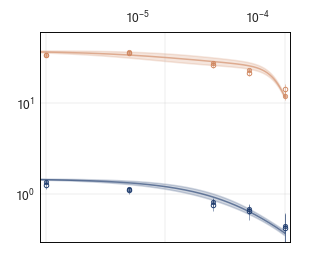

[[3.00000000e+00 1.00000000e+01 5.00000000e+01 2.50000000e+02
  5.00000000e+02 1.00000000e+03]
 [4.17000000e+01 3.36000000e+01 3.60000000e+01 2.71000000e+01
  2.28000000e+01 1.20000000e+01]
 [1.48000000e+00 1.40000000e+00 1.14000000e+00 8.00000000e-01
  6.20000000e-01 4.48000000e-01]
 [2.40000000e+00 2.30000000e+00 2.10000000e+00 1.50000000e+00
  1.20000000e+00 8.00000000e-01]
 [1.50673828e+00 1.42978723e+00 1.15834039e+00 8.11985019e-01
  6.28546020e-01 4.56521739e-01]]


In [108]:
# colors = ['#64dd17', '#c0ca33', '#ffab00', '#ef6c00']
colors = ['#cf855d', '#1a386b', '#709157', '#dbb43b', '#6892b3']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.95,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1
elw = 0.5

data_exp [0][0] = 3

ax1.set_xlim([9,1100])
# xp = np.linspace(9, 1000, 100)

ax12 = ax1.twiny()
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])
ax12.set_xscale('log')

ax1.set_yscale('log')
ax1.set_xscale('log')

xpow = np.linspace(calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1]), 1000)
ax1.plot(t1_theory[0,1:], 1e6*t1_theory[1,1:], lw=lw, alpha=0.6, c=colors[0], label='t1') 
ax1.fill_between(t1_theory[0,1:], 1e6*(t1_theory[1,1:]-3*t1_theory[2,1:]),1e6*(t1_theory[1,1:]+3*t1_theory[2,1:]), alpha = 0.2, color=colors[0])
# plt.plot(xpow,powerlaw(xpow,*fits[2]), lw=lw, alpha=0.6, c=colors[2], label='t rabi') 
ax1.plot(t2_theory[0,1:], t2_theory[1,1:]*1e6, lw=lw, alpha=0.6, c=colors[1], label='t2_theory') 
ax1.fill_between(t2_theory[0,1:], 1e6*(t2_theory[1,1:]-3*t2_theory[2,1:]),1e6*(t2_theory[1,1:]+3*t2_theory[2,1:]), alpha = 0.2, color=colors[1])
# plt.plot(xpow,powerlaw(xpow,*fits[3]), lw=lw, alpha=0.6, c=colors[3], label = 't phi')
# plt.plot(xpow,powerlaw(xpow,*fits[1]), lw=lw, alpha=0.6, c=colors[1], label = 't2') 

ax1.grid(linewidth = 0.3, alpha=0.5)

# plt.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = 0, mfc = colors[0], label = 'T1',alpha = 0.6)
# plt.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# plt.plot(data_exp[0], new_t_data[2], '.', mec=colors[0], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
# plt.plot(data_exp[0], new_t_data[5], '.', mec=colors[1], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
# plt.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], label = 'T2', alpha = 0.6)
# plt.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

# plt.errorbar(data_exp[0], new_t_data[1], yerr=3*new_t_err[1], fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)
# plt.errorbar(data_exp[0], new_t_data[2], yerr=3*new_t_err[2], fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)
# plt.errorbar(data_exp[0], new_t_data[4], yerr=3*new_t_err[4], fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
# plt.errorbar(data_exp[0], new_t_data[5], yerr=3*new_t_err[5], fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)

print(data_exp)

ax1.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = 0, mfc = colors[0], label = 'T1',alpha = 0.6)
ax1.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[2], '.', mec=colors[0], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[5], '.', mec=colors[1], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], label = 'T2', alpha = 0.6)
ax1.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))


#Combining fit_error and systematic error from T1 fluctuation
combined_error_T1_int = np.sqrt(np.asarray(2*new_t_err[1])**2+systematic_error_T1**2)
combined_error_T1_ext = np.sqrt(np.asarray(2*new_t_err[2])**2+systematic_error_T1**2)
combined_error_T2_int = np.sqrt(np.asarray(2*new_t_err[4])**2+systematic_error_T2**2)
combined_error_T2_ext = np.sqrt(np.asarray(2*new_t_err[5])**2+systematic_error_T2**2)
#confidence interval
c_interval = 1

#T1 only statistical error
# ax1.errorbar(data_exp[0], new_t_data[1], yerr=3*new_t_err[1], fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)
# ax1.errorbar(data_exp[0], new_t_data[2], yerr=3*new_t_err[2], fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)
#T1 also systematic error
ax1.errorbar(data_exp[0], new_t_data[1], yerr=c_interval*combined_error_T1_int, fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)
ax1.errorbar(data_exp[0], new_t_data[2], yerr=c_interval*combined_error_T1_ext, fmt='none', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)


#T2 only statistical error
# ax1.errorbar(data_exp[0], new_t_data[4], yerr=3*new_t_err[4], fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
# ax1.errorbar(data_exp[0], new_t_data[5], yerr=3*new_t_err[5], fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
#T2 also systematic error
ax1.errorbar(data_exp[0], new_t_data[4], yerr=c_interval*combined_error_T2_int, fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)
ax1.errorbar(data_exp[0], new_t_data[5], yerr=c_interval*combined_error_T2_ext, fmt='none', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)




ax1.set_ylim(0.3,60)
# ax1.legend(loc=2)



temp = ax1.get_ylim()

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)

# ax12.legend()

# ax1.set_xlim([-0.0,4.1])
# ax1.set_ylim([0.0,0.95])
# ax1.xaxis.set_major_locator(MultipleLocator(1))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
# ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

# ax1.yaxis.set_major_locator(MultipleLocator(0.2))
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig('fig4a_sys.svg')
plt.savefig('fig4a_sys.pdf')

In [109]:
#T1
data_exp[0], new_t_data[1], new_t_err[1], new_t_data[2], new_t_err[2]

(array([   3.,   10.,   50.,  250.,  500., 1000.]),
 array([38.60795301, 33.60775231, 35.98750635, 27.10179147, 22.85943572,
        12.04151311]),
 array([0.66150942, 0.36657167, 0.32093991, 0.35695021, 0.37447536,
        0.24482648]),
 array([38.60795301, 33.70261947, 35.38852312, 26.133152  , 21.13624106,
        14.16865794]),
 array([0.66150942, 0.91498308, 0.79321841, 0.7594532 , 0.67237595,
        0.66418234]))

In [110]:
#T2
data_exp[0], new_t_data[4], new_t_err[4], new_t_data[5], new_t_err[5]

(array([   3.,   10.,   50.,  250.,  500., 1000.]),
 array([1.49, 1.37, 1.13, 0.82, 0.69, 0.45]),
 array([0.03166283, 0.01943258, 0.02002808, 0.02211653, 0.02765743,
        0.03277405]),
 array([1.49      , 1.26158013, 1.11189712, 0.77260356, 0.65832462,
        0.42309408]),
 array([0.03166283, 0.05904593, 0.04539804, 0.0385603 , 0.05806904,
        0.05701269]))

In [111]:
data_exp = np.load('t1_exp_data.npy') # trigger, fridge, qubit, qubit cav temp, EO cav temp
data_exp[0] = save_data_exp[0]
data_exp[0][0] = 0

<IPython.core.display.Javascript object>


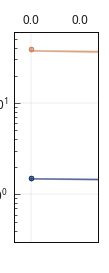

[-3.3945681690915804e-07, 1.3578272676366321e-06]


In [112]:
# colors = ['#64dd17', '#c0ca33', '#ffab00', '#ef6c00']
colors = ['#cf855d', '#1a386b', '#709157', '#dbb43b', '#6892b3']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(1,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1
elw = 0.5

ax1.set_xlim([-2,8])
ax12 = ax1.twiny()
print ([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])

xpow = np.linspace(calibration(0), calibration(ax1.get_xlim()[1]), 1000)
# ax12.plot(xpow,powerlaw(xpow,*fits[0]), lw=lw, alpha=0.6, c=colors[0], label='t1') 
ax1.plot(t1_theory[0,:], 1e6*t1_theory[1,:], lw=lw, alpha=0.6, c=colors[0], label='t1') 
ax1.fill_between(t1_theory[0,:], 1e6*(t1_theory[1,:]-3*t1_theory[2,:]),1e6*(t1_theory[1,:]+3*t1_theory[2,:]), alpha = 0.2, color=colors[0])
# ax12.plot(xpow,powerlaw(xpow,*fits[2]), lw=lw, alpha=0.6, c=colors[2], label='t rabi') 
ax1.plot(t2_theory[0,:], t2_theory[1,:]*1e6, lw=lw, alpha=0.6, c=colors[1], label='t2_theory') 
ax1.fill_between(t2_theory[0,:], 1e6*(t2_theory[1,:]-3*t2_theory[2,:]),1e6*(t2_theory[1,:]+3*t2_theory[2,:]), alpha = 0.2, color=colors[1])
# ax12.plot(xpow,powerlaw(xpow,*fits[3]), lw=lw, alpha=0.6, c=colors[3], label = 't phi') 
# ax12.plot(xpow,powerlaw(xpow,*fits[1]), lw=lw, alpha=0.6, c=colors[1], label = 't2') 


ax1.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[2], '.', mec=colors[0], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
# ax12.plot(data_exp[0], data_exp[3], '.', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax12.plot(data_exp[0], data_exp[4], '.', mec=colors[3], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[5], '.', mec=colors[1], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

ax1.plot(data_exp[0], new_t_data[1], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], new_t_data[4], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))


#statistical error
# ax1.errorbar(data_exp[0], new_t_data[1], yerr=3*new_t_err[1], fmt='.', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)

#also systematic error
ax1.errorbar(data_exp[0], new_t_data[1], yerr=c_interval*combined_error_T1_int, fmt='.', mec=colors[0], ms=ms, mew = 0, elinewidth=elw, mfc=colors[0], ecolor=colors[0], alpha=0.6)



# ax12.plot(data_exp[0], data_exp[3], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.6)
# ax12.plot(data_exp[0], data_exp[4], '.', mec=colors[3], ms=ms, mew = 0, mfc=colors[3], alpha=0.6)
# ax1.errorbar(data_exp[0], new_t_data[4], yerr=3*new_t_err[4], fmt='.', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)

#also statistical error
ax1.errorbar(data_exp[0], new_t_data[4], yerr=c_interval*combined_error_T2_int, fmt='.', mec=colors[1], ms=ms, mew = 0, elinewidth=elw, mfc=colors[1], ecolor=colors[1], alpha=0.6)


# ax12.plot(data_exp[0][0], data_exp[1][0], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax12.plot(data_exp[0][0], data_exp[3][0], '.', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# # ax12.plot(data_exp[0][0], data_exp[4][0], '.', mec=colors[3], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax12.plot(data_exp[0][0], data_exp[2][0], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

# ax12.plot(data_exp[0][0], data_exp[1][0], '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.6)
# ax12.plot(data_exp[0][0], data_exp[3][0], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.6)
# # ax12.plot(data_exp[0][0], data_exp[4][0], '.', mec=colors[3], ms=ms, mew = 0, mfc=colors[3], alpha=0.6)
# ax12.plot(data_exp[0][0], data_exp[2][0], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.6)


ax1.set_yscale('log')
ax12.set_yscale('log')
ax1.set_ylim(temp)


ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=True, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)


ax12.xaxis.set_major_locator(MultipleLocator(0.000001))
ax12.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax12.xaxis.set_minor_locator(MultipleLocator(0.0000005))

ax1.xaxis.set_major_locator(MultipleLocator(10))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(5))

# ax1.yaxis.set_major_locator(MultipleLocator(0.2))
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

if avg_flag:
    plt.savefig('fig4a2_avg.svg')
    plt.savefig('fig4a2_avg.pdf')
else:
    plt.savefig('fig4a2_sys.svg')
    plt.savefig('fig4a2_sys.pdf')    

# QND plots

In [7]:
fid1 = np.load("QND_Fid1.npy")
fid2 = np.load("QND_Fid2.npy")
qnd = np.load("QND.npy")
qnd_p = np.load("QNDprep.npy")
fid1_p = np.load("QND_Fid1prep.npy")
fid2_p = np.load("QND_Fid2prep.npy")
qnd_t = np.load("QND_theory.npy")
qnd_fid1_theory = np.load("QND_Fid1_theory.npy")
qnd_fid2_theory = np.load("QND_Fid2_theory.npy")
data_exp = np.load('mode_temp_data.npy')

In [32]:
qnd_fid1_theory

array([[0.00000000e+00, 1.00100100e+00, 2.00200200e+00, ...,
        9.97997998e+02, 9.98998999e+02, 1.00000000e+03],
       [9.56810413e-01, 9.55221380e-01, 9.54409716e-01, ...,
        7.64624090e-01, 7.64450556e-01, 7.64276946e-01],
       [2.37979547e-03, 2.06969946e-03, 1.99469373e-03, ...,
        1.46316638e-02, 1.46782648e-02, 1.47250395e-02]])

In [29]:
fid1

array([0.9525, 0.9465, 0.936 , 0.885 , 0.8305, 0.76  ])

In [30]:
fid2

array([0.916 , 0.9105, 0.902 , 0.8505, 0.7955, 0.717 ])

In [31]:
qnd

array([[0.9937 , 0.92206, 0.95788],
       [0.9945 , 0.9184 , 0.9565 ],
       [0.9907 , 0.92249, 0.956  ],
       [0.9842 , 0.9138 , 0.949  ],
       [0.9731 , 0.9033 , 0.9382 ],
       [0.95007, 0.8579 , 0.904  ]])

#### We still need to check the scaling for the xAxis here

<IPython.core.display.Javascript object>


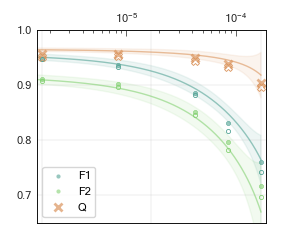

In [335]:
# colors = ['#64dd17', '#c0ca33', '#ffab00', '#ef6c00']
colors = ['#53a395', '#84d173', '#db955e', '#dbb43b']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.95,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1

ax1.set_xlim([9,1100])
ax12 = ax1.twiny()
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])
ax12.set_xscale('log')



xpow = np.linspace(calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1]), 1000)
ax1.plot(qnd_fid1_theory[0,1:],qnd_fid1_theory[1,1:], lw=lw, alpha=0.6, c=colors[0])
ax1.fill_between(qnd_fid1_theory[0,1:],qnd_fid1_theory[1,1:]-3*qnd_fid1_theory[2,1:],qnd_fid1_theory[1,1:]+3*qnd_fid1_theory[2,1:],color = colors[0], alpha = 0.1)
ax1.plot(qnd_fid2_theory[0,1:],qnd_fid2_theory[1,1:], lw=lw, alpha=0.6, c=colors[1])
ax1.fill_between(qnd_fid2_theory[0,1:],qnd_fid2_theory[1,1:]-3*qnd_fid2_theory[2,1:],qnd_fid2_theory[1,1:]+3*qnd_fid2_theory[2,1:],color = colors[1], alpha = 0.1)
ax1.plot(qnd_t[0,1:],qnd_t[1,1:], lw=lw, alpha=0.6, c=colors[2])
ax1.fill_between(qnd_t[0,1:],qnd_t[1,1:]-3*qnd_t[2,1:],qnd_t[1,1:]+3*qnd_t[2,1:],color = colors[2], alpha = 0.1)


ax1.grid(linewidth = 0.3, alpha=0.5)

ax1.plot(data_exp[0, 1:], fid1[1:], '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0, 1:], fid1_p[1:], '.', mec=colors[0], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0, 1:], fid2_p[1:], '.', mec=colors[1], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0, 1:], fid2[1:], '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax1.plot(data_exp[0], QND[1:,2], 'x', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

ax1.plot(data_exp[0, 1:], fid1[1:], '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.6, label = 'F1')
ax1.plot(data_exp[0, 1:], fid2[1:], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.6, label = 'F2')
# ax1.plot(data_exp[0], QND[1:,2], 'x', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.6)

ax1.plot(data_exp[0, 1:], qnd[1:,2], 'x', c=colors[2], mew=2, alpha=0.7, ms=ms, label = 'Q')
ax1.plot(data_exp[0, 1:], qnd_p[1:,2], 'X',color=colors[2], markerfacecolor='none', markeredgecolor=colors[2], mew=mew*1.5, ms=ms)


# ax1.set_yscale('log')
ax1.set_xscale('log')

ax1.set_ylim([0.65,1.0])

temp = ax1.get_ylim()

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=False, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)

ax1.legend()

# ax1.set_xlim([-0.0,4.1])
ax1.set_ylim(top=1.0)
temp = ax1.get_ylim()
# ax1.xaxis.set_major_locator(MultipleLocator(1))
# ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
# ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.1))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.05))

if avg_flag:
    plt.savefig('fig4c_avg.svg')
    plt.savefig('fig4c_avg.pdf')
else:
    plt.savefig('fig4c.svg')
    plt.savefig('fig4c.pdf')

<IPython.core.display.Javascript object>


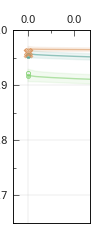

[-3.3945681690915804e-07, 1.3578272676366321e-06]


In [336]:
colors = ['#53a395', '#84d173', '#db955e', '#dbb43b']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(1,2.5))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 1


ax1.set_xlim([-2,8])
ax12 = ax1.twiny()
print ([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])
ax12.set_xlim([calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1])])



xpow = np.linspace(calibration(ax1.get_xlim()[0]), calibration(ax1.get_xlim()[1]), 1000)
ax1.plot(qnd_fid1_theory[0,:],qnd_fid1_theory[1,:], lw=lw, alpha=0.6, c=colors[0], label='F1')
ax1.fill_between(qnd_fid1_theory[0,:],qnd_fid1_theory[1,:]-3*qnd_fid1_theory[2,:],qnd_fid1_theory[1,:]+3*qnd_fid1_theory[2,:],color = colors[0], alpha = 0.1)
ax1.plot(qnd_fid2_theory[0,:],qnd_fid2_theory[1,:], lw=lw, alpha=0.6, c=colors[1], label='F2')
ax1.fill_between(qnd_fid2_theory[0,:],qnd_fid2_theory[1,:]-3*qnd_fid2_theory[2,:],qnd_fid2_theory[1,:]+3*qnd_fid2_theory[2,:],color = colors[1], alpha = 0.1)
ax1.plot(qnd_t[0,:],qnd_t[1,:], lw=lw, alpha=0.6, c=colors[2], label='QND')
ax1.fill_between(qnd_t[0,:],qnd_t[1,:]-3*qnd_t[2,:],qnd_t[1,:]+3*qnd_t[2,:],color = colors[2], alpha = 0.1)

ax1.grid(linewidth = 0.3, alpha=0.5)

ax1.plot(data_exp[0], fid1, '.', mec=colors[0], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], fid1_p, '.', mec=colors[0], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], fid2_p, '.', mec=colors[1], ms=ms, mew = mew*1.5, mfc=(0, 0, 0, 0.0))
ax1.plot(data_exp[0], fid2, '.', mec=colors[1], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))
# ax1.plot(data_exp[0], QND[1:,2], 'x', mec=colors[2], ms=ms, mew = mew, mfc=(0, 0, 0, 0.0))

ax1.plot(data_exp[0], fid1, '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.6)
ax1.plot(data_exp[0], fid2, '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.6)
# ax1.plot(data_exp[0], QND[1:,2], 'x', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.6)

ax1.plot(data_exp[0], qnd[:,2], 'x', c=colors[2], mew=2, alpha=0.7, ms=ms)
ax1.plot(data_exp[0], qnd_p[:,2], 'X',color=colors[2], markerfacecolor='none', markeredgecolor=colors[2], mew=mew*1.5, ms=ms)



ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.tick_params(axis="both", which="both", bottom=False, top=False,    
                labelbottom=False, left=True, right=False, labelleft=True, width=0.5)
ax12.xaxis.label.set_color(color)
ax12.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax12.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)


ax12.xaxis.set_major_locator(MultipleLocator(0.000001))
ax12.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax12.xaxis.set_minor_locator(MultipleLocator(0.0000005))

ax1.xaxis.set_major_locator(MultipleLocator(10))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(5))

ax1.yaxis.set_major_locator(MultipleLocator(0.1))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.05))




ax1.set_ylim(temp)
if avg_flag:
    plt.savefig('fig4c2_avg.svg')
    plt.savefig('fig4c2_avg.pdf')
else:
    plt.savefig('fig4c2.svg')
    plt.savefig('fig4c2.pdf')

In [220]:
ax12.get_xlim()

(-3.3945681690915804e-07, 1.3578272676366321e-06)